# How to chunk text into paragraphs — Part 3: doing it in real time, on a CPU

Welcome back! In the first article of this series we split text into paragraphs by building a big sentence-similarity matrix and reading off its valleys. It worked nicely =).

But two things were quietly bugging me. First, just to embed the sentences we had to load a 420 MB model. And second — the bigger one — we needed the **whole** text in front of us before we could even start, because the whole trick lives in that n×n matrix. So if a podcast transcript is coming in live, sentence by sentence, the old approach just sits there and waits for the very last sentence to arrive.

In this article I want to fix both. We are going to make our chunker:

- use **static embeddings** — microseconds per sentence, no GPU, a tiny ~30 MB model;
- work in a **single pass**, deciding the paragraph breaks *on the fly*, as each sentence arrives.

Same idea as before, just real-time and on a laptop. Let's go.

## The two things we want to kill

Remember our recipe from Part 1? Embed the sentences, build the cosine-similarity matrix, apply the reversed-sigmoid activation, and read off the valleys. It gave us nice paragraphs.

But it hides two costs:

1. A **420 MB transformer**, just to turn sentences into vectors. Without a GPU, that is slow.
2. An **O(n²) matrix** that needs the *entire* document up front. No streaming, no real time.

Let's deal with them one at a time.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pysbd
from model2vec import StaticModel
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import argrelextrema

In [2]:
text = open("../data/podcast_transcript.txt").read()
seg = pysbd.Segmenter(language="en", clean=False)
sentences = seg.segment(text)
print(len(sentences), "sentences;  first:", sentences[0][:70])

1064 sentences;  first: In the year 1625, an Italian nobleman named Pietro de la Valet went on


## Step 1: trade the 420 MB transformer for static embeddings

Here is a neat trick I really like. A library called Model2Vec takes a sentence-transformer and *distills* it into **static** embeddings — basically a lookup table of token vectors. No neural forward pass anymore; we just look the tokens up and average them. The result is hundreds of times faster, runs happily on a CPU, and the model is only ~30 MB on disk.

Let's load it, time it, and — because throwing away the big model sounds a little reckless — double-check it still tells topics apart. Remember in Part 1 our pet sentences looked similar while the embeddings sentence wandered off in its own direction (that famous −0.07)? We want the same kind of clean separation here.

In [3]:
static = StaticModel.from_pretrained("minishlab/potion-base-8M")

def embed(s):
    v = np.asarray(static.encode(s), dtype=np.float32)
    return v / (np.linalg.norm(v) + 1e-9)        # L2-normalize -> cosine is just a dot product

t0 = time.perf_counter()
_ = [embed(s) for s in sentences]
print(f"{(time.perf_counter()-t0)/len(sentences)*1e6:.0f} us/sentence on CPU, model ~30 MB on disk")

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

78 us/sentence on CPU, model ~30 MB on disk


In [4]:
# sanity check: do static embeddings still tell topics apart?
a, b, c = embed("The cat sat on the mat."), embed("My dog chased the ball."), embed("Q3 revenue beat estimates.")
print("pet~pet", round(float(a@b), 3), "  pet~finance", round(float(a@c), 3))   # want pet~pet >> pet~finance

pet~pet 0.063   pet~finance -0.075


## Step 2: split on the fly, without the matrix

This is the part I'm most excited about. Instead of staring at *all* the sentences at once, let's read them one at a time, the way a human listens to a podcast.

The idea is simple. We keep a running "summary" of the paragraph we are currently in — just the average of its sentence vectors so far. For each new sentence we ask one question: *is this still about the same thing as the paragraph so far?* If it is still similar to that running average, it belongs — we add it in. If the similarity suddenly drops, the topic has changed: we close the paragraph and start a fresh one with this sentence.

That's the whole algorithm. One pass, no matrix, no peeking ahead. Here it is:

In [5]:
def stream_chunks(sentences, embed, threshold=0.10):
    chunk, centroid, n = [], None, 0
    for s in sentences:
        v = embed(s)                              # static embedding -- microseconds
        if centroid is None:
            chunk, centroid, n = [s], v, 1
            continue
        if float(v @ centroid) < threshold:       # drifted away -> boundary, on the fly
            yield " ".join(chunk)
            chunk, centroid, n = [s], v, 1
        else:
            chunk.append(s); n += 1
            centroid = centroid + (v - centroid) / n   # online mean update
    if chunk:
        yield " ".join(chunk)

toy = ["I love training neural networks.", "Backprop tunes the weights.",
       "Yesterday I baked sourdough bread.", "The crust came out crispy."]
print("toy ->", len(list(stream_chunks(toy, embed))), "chunks (expect 2: ML vs baking)")

chunks = list(stream_chunks(sentences, embed))
print(len(chunks), "chunks from the transcript;  first:\n", chunks[0][:200])

toy -> 2 chunks (expect 2: ML vs baking)
202 chunks from the transcript;  first:
 In the year 1625, an Italian nobleman named Pietro de la Valet went on a tour of the Middle East.  De la Valle was a prolific traveler.  He journeyed around Asia, North Africa and even India.  He marr


## So… how fast is it, really?

Talk is cheap, let's measure =). We'll grow the document and time the actual chunking work — embedding plus finding the boundaries. (Sentence splitting is the same for both methods, so we leave it out of the race.) The old matrix method we stop where its n×n table stops being practical.

And speed is only half the question — fast *and wrong* is no good. So right after, we'll check that the paragraphs the streaming method finds are basically the same ones Part 1 would have given us.

In [6]:
minilm = SentenceTransformer("all-MiniLM-L6-v2")
def rev_sigmoid(x): return 1 / (1 + np.exp(0.5 * x))

def matrix_split(emb):                            # Part 1's O(n^2) boundary finder, given embeddings
    sim = cosine_similarity(emb); N = len(emb); p = min(10, N)
    w = np.pad(np.vectorize(rev_sigmoid)(np.linspace(-10, 10, p)), (0, N - p))
    diags = np.stack([np.pad(sim.diagonal(k), (0, N - len(sim.diagonal(k)))) for k in range(N)])
    return argrelextrema(np.sum(diags * w.reshape(-1, 1), axis=0), np.less, order=2)[0]

def stream_split(V, threshold=0.10):              # our O(n) boundary finder, given embeddings
    c, n, cuts = None, 0, 0
    for v in V:
        if c is None: c, n = v, 1; continue
        if float(v @ c) < threshold: cuts += 1; c, n = v, 1
        else: n += 1; c = c + (v - c) / n
    return cuts

def normed(M):
    M = np.asarray(M, np.float32); return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
def T(fn, reps=2):
    fn(); best = 1e9
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

big = sentences * ((8000 // len(sentences)) + 1)   # scale the transcript up
cap = 2000                                         # the O(n^2) matrix's practical ceiling
rows = []
for n in [50, 100, 250, 500, 1000, 2000, 4000, 8000]:
    sub = big[:n]
    t_se = T(lambda: static.encode(sub)); Vs = normed(static.encode(sub)); t_ss = T(lambda: stream_split(Vs))
    if n <= cap:
        t_me = T(lambda: minilm.encode(sub), 1); Em = minilm.encode(sub); t_ms = T(lambda: matrix_split(Em), 1)
        rows.append((n, t_me + t_ms, t_se + t_ss))
    else:
        rows.append((n, None, t_se + t_ss))
    b = rows[-1][1]
    print(f"n={n:5d}   Part1 = {('%.3fs' % b) if b else 'matrix memory wall':>18}   Part3 = {rows[-1][2]:.4f}s")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

n=   50   Part1 =             0.024s   Part3 = 0.0014s


n=  100   Part1 =             0.064s   Part3 = 0.0021s


n=  250   Part1 =             0.096s   Part3 = 0.0048s


n=  500   Part1 =             0.176s   Part3 = 0.0121s


n= 1000   Part1 =             0.387s   Part3 = 0.0163s


n= 2000   Part1 =             0.627s   Part3 = 0.0325s


n= 4000   Part1 = matrix memory wall   Part3 = 0.0660s


n= 8000   Part1 = matrix memory wall   Part3 = 0.1248s


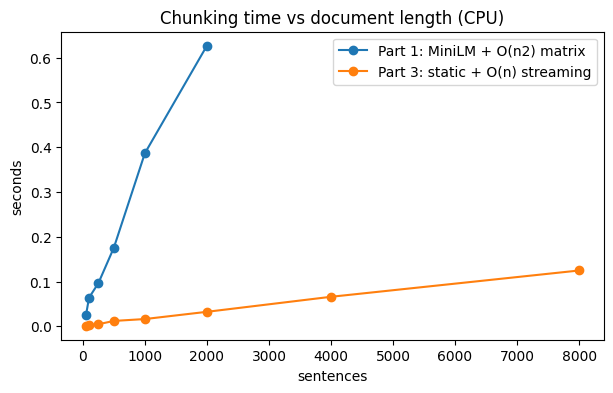

At 2000 sentences: 0.627s -> 0.0325s = 19x faster -- and Part 3 keeps going where the n x n matrix runs out of memory.


In [7]:
ns = [r[0] for r in rows]; new = [r[2] for r in rows]
bx = [r[0] for r in rows if r[1]]; by = [r[1] for r in rows if r[1]]
plt.figure(figsize=(7, 4))
plt.plot(bx, by, "o-", label="Part 1: MiniLM + O(n2) matrix")
plt.plot(ns, new, "o-", label="Part 3: static + O(n) streaming")
plt.xlabel("sentences"); plt.ylabel("seconds"); plt.legend()
plt.title("Chunking time vs document length (CPU)"); plt.show()

both = [r for r in rows if r[1]]; n0, tb, tn = both[-1]
print(f"At {n0} sentences: {tb:.3f}s -> {tn:.4f}s = {tb/tn:.0f}x faster "
      f"-- and Part 3 keeps going where the n x n matrix runs out of memory.")

In [8]:
# quality: are the streaming boundaries comparable to Part 1's? (on the REAL, un-scaled transcript)
def cut_indices(chunks):
    cuts, acc = set(), 0
    for ch in chunks[:-1]:
        acc += len(seg.segment(ch)); cuts.add(acc)
    return cuts
base_idx = set(matrix_split(minilm.encode(sentences)).tolist())
new_idx  = cut_indices(chunks)
agree = sum(any(abs(b - x) <= 1 for x in base_idx) for b in new_idx) / max(len(new_idx), 1)
print(f"{len(chunks)} streaming chunks vs ~{len(base_idx)+1} Part-1 chunks; "
      f"{agree:.0%} of streaming cuts land within +/-1 sentence of a Part-1 cut")

202 streaming chunks vs ~200 Part-1 chunks; 63% of streaming cuts land within +/-1 sentence of a Part-1 cut


## Watching it work, live

Here's the fun part, and honestly the whole reason we did all of this. Because we only ever look forward, the chunker works on a **stream** — exactly like a transcript arriving live from Whisper, sentence by sentence. Let's feed it the sentences one at a time and watch the paragraphs appear by themselves, together with the similarity score that triggers each break.

In [9]:
def stream_live(sentences, embed, threshold=0.10):
    chunk, c, n, sims, cuts = [], None, 0, [], []
    for i, s in enumerate(sentences):
        v = embed(s)
        sim = 1.0 if c is None else float(v @ c); sims.append(sim)
        if c is not None and sim < threshold:
            cuts.append(i); print("---- new paragraph ----")
            chunk, c, n = [s], v, 1
        else:
            if c is None: chunk, c, n = [s], v, 1
            else: chunk.append(s); n += 1; c = c + (v - c) / n
        print(f"  [{sim:+.2f}] {s[:66]}")
    return sims, cuts

sims, cuts = stream_live(sentences[:45], embed)

  [+1.00] In the year 1625, an Italian nobleman named Pietro de la Valet wen
  [+0.26] De la Valle was a prolific traveler. 
  [+0.14] He journeyed around Asia, North Africa and even India. 
  [+0.26] He married an Assyrian Christian princess in Damascus and now the 
  [+0.25] At this time, travel in this region couldn't have been more danger
---- new paragraph ----
  [+0.06] The Ottoman and Persian empires were at war, fighting over who wou
  [+0.18] And meanwhile, local bandits took advantage of the chaos to prey o
  [+0.22] In those days, lions even roamed in these hills. 
  [+0.16] Due to these various dangers, dela Valets guides were constantly o
  [+0.15] It was June 18, 1625 when they spotted a distant group of tribesme
  [+0.22] Their guides decided that they might be in danger and began to sea
  [+0.23] In the distance, they spotted the looming mass of a series of enor
  [+0.25] As Dela Valley later wrote in his memoirs being suspicious to some
  [+0.28] Dela Valet's group sta

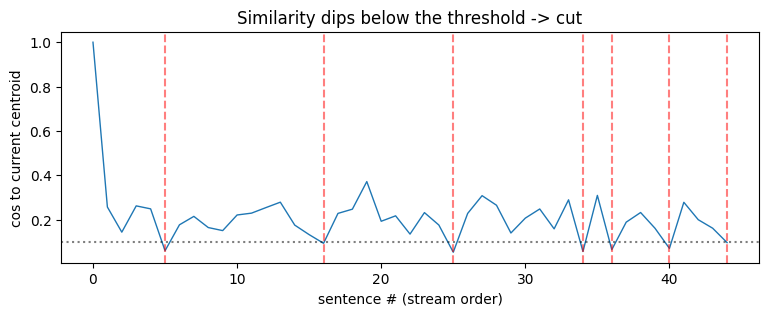

In [10]:
plt.figure(figsize=(9, 3))
plt.plot(sims, lw=1)
for cct in cuts: plt.axvline(cct, color="r", ls="--", alpha=.5)
plt.axhline(0.10, color="k", ls=":", alpha=.5)
plt.xlabel("sentence # (stream order)"); plt.ylabel("cos to current centroid")
plt.title("Similarity dips below the threshold -> cut"); plt.show()

## A few honest caveats

**Picking the threshold.** Static embeddings live close to zero, so the magic number isn't 0.5 like you might expect. The honest way to choose it is to plot the distribution of similarities and drop the line into the valley. Here that lands around 0.10 — which, nicely enough, gives about the same number of paragraphs Part 1 produced on this transcript.

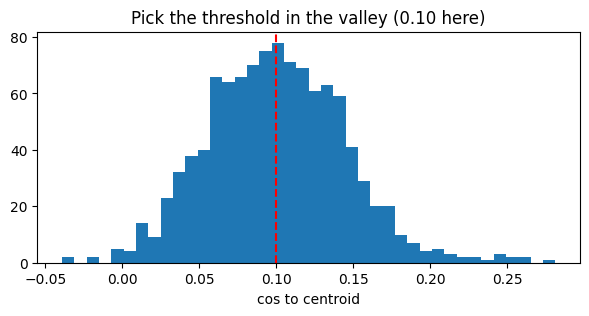

In [11]:
def centroid_sims(sentences, embed):
    c, n, out = None, 0, []
    for s in sentences:
        v = embed(s)
        if c is None: c, n = v, 1; continue
        out.append(float(v @ c)); c = c + (v - c) / (n + 1); n += 1
    return out
plt.figure(figsize=(7, 3)); plt.hist(centroid_sims(sentences, embed), bins=40)
plt.axvline(0.10, color="r", ls="--"); plt.title("Pick the threshold in the valley (0.10 here)")
plt.xlabel("cos to centroid"); plt.show()

**Centroid drift.** Over a long paragraph, the running average slowly drifts away from where the paragraph began. An easy fix is to average only the *last few* sentences instead of the whole paragraph — a trailing window. (Comparing each sentence to a recent baseline, instead of to a fixed number, is another way to do it.)

In [12]:
def stream_chunks_window(sentences, embed, threshold=0.10, k=5):
    chunk, vecs = [], []
    for s in sentences:
        v = embed(s)
        if not chunk: chunk, vecs = [s], [v]; continue
        c = np.mean(vecs[-k:], axis=0); c = c / (np.linalg.norm(c) + 1e-9)
        if float(v @ c) < threshold: yield " ".join(chunk); chunk, vecs = [s], [v]
        else: chunk.append(s); vecs.append(v)
    if chunk: yield " ".join(chunk)
print(len(list(stream_chunks_window(sentences, embed))), "chunks (trailing-window variant, k=5)")

104 chunks (trailing-window variant, k=5)


---

And that's it — semantic chunking **in real time, on a CPU**, in a single pass =). Same idea we started with two articles ago, just a lot lighter, and now fast enough to keep up with a live stream.

## What is next

- There are smarter split rules — adjacent-sentence smoothing, a rolling percentile threshold — which I will cover in coming articles;
- The very same trick works for other languages if you swap in a multilingual static model;
- And all of this powers our podcast summarization project — `pip install quintessentia`.

Thank you all for reading! Please follow me on Medium and LinkedIn, and feel free to ask any questions. And if this helped you, don't forget to star the project on GitHub =).